# From association to longitudinal TMLE with the TWINS data

This notebook is an end-to-end causal analysis with `cleverly`. It starts with a crude contrast, builds g-computation and inverse-probability weighting by hand, then moves through every point-treatment TMLE method that is appropriate for this question: ordinary TMLE, stacked and fold-evaluated CV-TMLE, collaborative TMLE (C-TMLE), doubly robust-inference TMLE (DR-TMLE), and TMLE with a Super Learner. It finishes with diagnostics, sensitivity analysis, multiple estimands, and a two-time longitudinal TMLE (LTMLE) extension.

The goal is to learn the workflow and the estimators, **not to make a clinical claim**. Low birth weight is a post-conception state rather than a directly assignable treatment, and the public data do not contain every common cause of birth weight and mortality. Read causal estimates below as illustrations conditional on the stated identification assumptions.

By the end, you should be able to:

- distinguish an observed association from an identified causal estimand;
- explain how g-computation, IPW, and TMLE use the outcome and treatment mechanisms;
- choose among ordinary TMLE, CV-TMLE, C-TMLE, and DR-TMLE;
- inspect support, score equations, nuisance fits, and omitted-variable sensitivity; and
- encode a time-ordered treatment question for LTMLE.

## 1. Setup and reproducibility

Run this notebook from the project environment (`uv sync --extra dev`). The data URLs are pinned to the CEVAE repository commit used when this notebook was published. The analysis samples twin pairs, not individual children, so both twins are always retained together.

In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import cleverly
from cleverly import (
    ATC,
    ATE,
    ATT,
    CausalStudy,
    CollaborativeTMLEMethod,
    CounterfactualMean,
    CrossFitting,
    DRTMLEMethod,
    Inference,
    LongitudinalTreatment,
    ModelSpec,
    OddsRatio,
    PointTreatment,
    PopulationAttributableFraction,
    PopulationAttributableRisk,
    RegimeContrast,
    RiskRatio,
    Runtime,
    SuperLearner,
    TMLEMethod,
)

SEED = 2026
N_PAIRS = 6_000
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=UserWarning)

## 2. Load and understand TWINS

The [CEVAE TWINS directory](https://github.com/AMLab-Amsterdam/CEVAE/tree/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS) derives same-sex US twin pairs born in 1989–1991 from linked birth and infant-death records. Its three files contain pair covariates (`X`), both birth weights (`T`), and both three-year mortality outcomes (`Y`). The original README points to the NBER linked birth/infant-death source and Almond, Chay, and Lee (2005).

We reshape from one pair per row to one child per row. `pair_id` remains in the design so that cleverly keeps twins in the same cross-fitting fold and computes cluster-robust inference.

In [2]:
COMMIT = "9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd"
BASE_URL = f"https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/{COMMIT}/datasets/TWINS"
FILES = {
    "X": "twin_pairs_X_3years_samesex.csv",
    "T": "twin_pairs_T_3years_samesex.csv",
    "Y": "twin_pairs_Y_3years_samesex.csv",
}
raw = {name: pd.read_csv(f"{BASE_URL}/{filename}") for name, filename in FILES.items()}

assert raw["X"].shape[0] == raw["T"].shape[0] == raw["Y"].shape[0]
assert np.array_equal(raw["T"]["Unnamed: 0"], raw["Y"]["Unnamed: 0"])
{name: frame.shape for name, frame in raw.items()}

{'X': (71345, 54), 'T': (71345, 3), 'Y': (71345, 3)}

In [3]:
pair_rows = raw["X"].sample(n=N_PAIRS, random_state=SEED).index.sort_values().to_numpy()
X = raw["X"].loc[pair_rows].reset_index(drop=True)
T = raw["T"].loc[pair_rows].reset_index(drop=True)
Y = raw["Y"].loc[pair_rows].reset_index(drop=True)

shared = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "preterm",
    "tobacco",
    "alcohol",
    "mpre5",
    "nprevistq",
    "phyper",
]
children = []
for twin in (0, 1):
    child = X[shared].copy()
    child["pair_id"] = np.arange(N_PAIRS)
    child["twin"] = twin
    child["birth_order"] = X[f"bord_{twin}"]
    child["birth_weight_g"] = T[f"dbirwt_{twin}"]
    child["mortality_3y"] = Y[f"mort_{twin}"].astype(int)
    children.append(child)

twins = pd.concat(children, ignore_index=True).sort_values(["pair_id", "twin"])
twins["low_birth_weight"] = (twins["birth_weight_g"] < 2_500).astype(int)
twins.shape

(12000, 20)

The adjustment set below is deliberately explicit. It uses demographic, pregnancy-risk, and twin-specific birth-order variables available before the birth-weight measurement. Missing covariates receive deterministic median/mode-style imputation plus a missingness indicator. That is a transparent teaching choice, not a general solution to missing confounders; a real analysis would justify a missing-data estimand and model.

In [4]:
BASE_ADJUSTMENT = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "phyper",
    "preterm",
    "tobacco",
    "alcohol",
    "birth_order",
]
point_data = twins.copy()
missing_indicators = []
for column in BASE_ADJUSTMENT:
    missing = point_data[column].isna()
    if missing.any():
        indicator = f"{column}_missing"
        point_data[indicator] = missing.astype(int)
        missing_indicators.append(indicator)
    point_data[column] = point_data[column].fillna(point_data[column].median()).astype(float)

ADJUSTMENT = (*BASE_ADJUSTMENT, *missing_indicators)
summary = pd.DataFrame(
    {
        "n_children": [len(point_data)],
        "n_pairs": [point_data["pair_id"].nunique()],
        "low_birth_weight": [point_data["low_birth_weight"].mean()],
        "mortality_3y": [point_data["mortality_3y"].mean()],
        "discordant_weight_pairs": [
            point_data.groupby("pair_id")["low_birth_weight"].nunique().eq(2).mean()
        ],
    }
)
summary

,n_children,n_pairs,low_birth_weight,mortality_3y,discordant_weight_pairs
0,12000,6000,0.5145,0.0359,0.215


## 3. Start with the association

Let $A$ indicate birth weight below 2,500 g and $Y$ indicate mortality by age three. The crude risk difference is $E(Y\mid A=1)-E(Y\mid A=0)$. It is a description of these observed children, not yet $E(Y^1-Y^0)$: the two birth-weight groups differ in common causes of exposure and outcome.

In [5]:
observed_risks = point_data.groupby("low_birth_weight")["mortality_3y"].mean()
crude_rd = observed_risks.loc[1] - observed_risks.loc[0]
pd.DataFrame(
    {
        "observed_risk": observed_risks,
        "children": point_data["low_birth_weight"].value_counts().sort_index(),
    }
).rename_axis("low_birth_weight").assign(crude_risk_difference=crude_rd)

,observed_risk,children,crude_risk_difference
low_birth_weight,,,
0,0.0043,5826,0.0615
1,0.0658,6174,0.0615


Observed mortality is 0.0043 without low birth weight and 0.0658 with it, roughly fifteen times
higher, for a crude risk difference of 0.0615. Hold on to that number: everything that follows either subtracts confounding from it or
quantifies what would have to be true for the adjusted version to be wrong.

## 4. Identify the causal question before choosing a method

Our illustrative target is the population average treatment effect (ATE), $\psi=E(Y^1)-E(Y^0)$. Under consistency, conditional exchangeability given `ADJUSTMENT`, and positivity, it is identified by the g-formula. Calling `identify` makes those commitments visible before a learner is fit.

The cluster declaration changes folds and variance estimation; it does not remove confounding by itself.

In [6]:
point_study = CausalStudy(
    point_data,
    design=PointTreatment(
        outcome="mortality_3y",
        treatment="low_birth_weight",
        adjustment=ADJUSTMENT,
        cluster="pair_id",
        outcome_family="binomial",
    ),
)
ate_effect = point_study.identify(ATE(reference=0))
print(ate_effect.summary())
pd.DataFrame([vars(item) for item in ate_effect.available_methods()])

average treatment effect, E[Y^a] - E[Y^reference]
identified by explicit-adjustment: E_W[E(Y | A=a, W)] and the declared smooth contrast
adjustment/history: ['mager8', 'meduc6', 'mrace', 'dmar', 'mplbir_reg', 'data_year', 'diabetes', 'chyper', 'phyper', 'preterm', 'tobacco', 'alcohol', 'birth_order', 'meduc6_missing', 'mplbir_reg_missing', 'diabetes_missing', 'chyper_missing', 'phyper_missing', 'preterm_missing', 'tobacco_missing', 'alcohol_missing', 'birth_order_missing']
assumptions:
  - consistency: Y = Y^a when A = a
  - no unmeasured confounding: Y^a is independent of A given W
  - positivity: 0 < P(A = 1 | W) < 1 almost surely, so both counterfactual means are supported by data at every covariate value


,name,available,reason
0,tmle,True,NaN
1,collaborative_tmle,True,NaN
2,drtmle,True,NaN
3,riesz_tmle,False,the direct-Riesz engine and intervention-state...
4,ep,False,EP requires a conditional-contrast estimand an...


Two things in that output are worth pausing on.

The summary prints the assumptions *before* any model is fitted, and it prints the realized
adjustment set — note that the nine `*_missing` indicators created above are now part of it, which
is what makes the imputation an explicit modelling choice rather than a silent one.

The methods table declares what this estimand and design can support. `tmle`, `collaborative_tmle`,
and `drtmle` are available; `riesz_tmle` and `ep` are not, each with a stated reason. That table is
the machine-checked version of the argument section 10 makes in prose — an unavailable method is a
statement about the scientific question, not a missing feature.

## 5. The estimator ladder: g-computation and IPW

Before TMLE, it helps to see its two nuisance functions separately.

- **G-computation** estimates $Q(a,W)=E(Y\mid A=a,W)$ and averages predictions after setting every row to $a=1$ and $a=0$. It relies on a good outcome regression.
- **Inverse-probability weighting (IPW)** estimates $g(W)=P(A=1\mid W)$ and reweights observed outcomes to emulate both intervention groups. It relies on a good treatment mechanism and can become unstable near probabilities 0 or 1.
- **TMLE** uses both, updates the initial outcome regression along a least-favorable submodel, and solves the efficient influence-function score. It is doubly robust for consistency and provides influence-curve inference.

The hand-built estimates below are point estimates only; the cleverly results later supply clustered uncertainty and diagnostics.

In [7]:
def scaled_logistic():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=3_000),
    )


W = point_data.loc[:, ADJUSTMENT]
A = point_data["low_birth_weight"].to_numpy()
outcome = point_data["mortality_3y"].to_numpy()

q_model = scaled_logistic().fit(pd.concat([point_data[["low_birth_weight"]], W], axis=1), outcome)
counterfactual_risks = {}
for arm in (0, 1):
    design = pd.concat([point_data[["low_birth_weight"]], W], axis=1).copy()
    design["low_birth_weight"] = arm
    counterfactual_risks[arm] = q_model.predict_proba(design)[:, 1].mean()
gcomp_ate = counterfactual_risks[1] - counterfactual_risks[0]

g_model = scaled_logistic().fit(W, A)
g1 = np.clip(g_model.predict_proba(W)[:, 1], 0.01, 0.99)
ipw_ate = np.mean(A * outcome / g1) - np.mean((1 - A) * outcome / (1 - g1))

pd.DataFrame(
    {
        "method": ["crude association", "g-computation", "IPW (1% truncation)"],
        "risk_difference": [crude_rd, gcomp_ate, ipw_ate],
    }
)

,method,risk_difference
0,crude association,0.0615
1,g-computation,0.0574
2,IPW (1% truncation),0.0580


Both adjusted estimates fall below the crude 0.0615, and they land within 0.0006 of each other
despite using disjoint models — g-computation never looks at the propensity score and IPW never
looks at the outcome regression. Agreement between two estimators that share no nuisance model is
mild evidence that neither is badly misspecified. It is not evidence about confounding: both adjust
for the same covariate set and would inherit the same omission from it.

The IPW estimate also depends on a truncation choice (`np.clip(..., 0.01, 0.99)`) that
g-computation never has to make. Keep that in mind when the two appear as neighbouring rows later.

G-computation used the outcome model and ignored the treatment model. IPW did the reverse. Neither
is efficient, and IPW in particular discarded the outcome regression entirely. TMLE is the third
rung of this ladder, and it is short enough to build by hand.

### The targeting step, by hand

Take the initial outcome regression $\bar Q^0(A,W)$ and move it along a one-parameter *submodel*
indexed by $\epsilon$:

$$\operatorname{logit}\bar Q^\epsilon(A,W)=\operatorname{logit}\bar Q^0(A,W)+\epsilon\,H(A,W),
\qquad H(A,W)=\frac{A}{g(W)}-\frac{1-A}{1-g(W)}.$$

$H$ is the **clever covariate**. It is not a covariate in the modelling sense — it carries no new
information about the outcome — it is chosen so that the score of this submodel at $\epsilon=0$
*equals* the efficient influence function of the ATE. That is what "least favourable" means: among
all the ways to perturb $\bar Q^0$, this direction is the hardest one for the target parameter, so
fitting $\epsilon$ by maximum likelihood forces the estimator to solve

$$\frac{1}{n}\sum_i H(A_i,W_i)\bigl(Y_i-\bar Q^{\hat\epsilon}(A_i,W_i)\bigr)=0,$$

the empirical efficient-score equation. Solving it is what makes the estimator asymptotically
linear, which in turn is what licenses influence-curve confidence intervals. Below we solve the
one-dimensional score equation directly by Newton's method so the mechanism is visible; `cleverly`
fits the same fluctuation as a weighted logistic regression with an offset.

In [8]:
def expit(value):
    return 1.0 / (1.0 + np.exp(-value))


def logit(probability):
    clipped = np.clip(probability, 1e-12, 1 - 1e-12)
    return np.log(clipped / (1 - clipped))


design_all = pd.concat([point_data[["low_birth_weight"]], W], axis=1)
q_obs = q_model.predict_proba(design_all)[:, 1]
q1 = q_model.predict_proba(design_all.assign(low_birth_weight=1))[:, 1]
q0 = q_model.predict_proba(design_all.assign(low_birth_weight=0))[:, 1]

clever_covariate = A / g1 - (1 - A) / (1 - g1)
initial_score = np.mean(clever_covariate * (outcome - q_obs))

epsilon = 0.0
for _ in range(50):
    q_star = expit(logit(q_obs) + epsilon * clever_covariate)
    step = np.mean(clever_covariate * (outcome - q_star)) / np.mean(
        clever_covariate**2 * q_star * (1 - q_star)
    )
    epsilon += step
    if abs(step) < 1e-12:
        break

targeted_score = np.mean(
    clever_covariate * (outcome - expit(logit(q_obs) + epsilon * clever_covariate))
)
q1_star = expit(logit(q1) + epsilon / g1)
q0_star = expit(logit(q0) - epsilon / (1 - g1))
manual_tmle_ate = q1_star.mean() - q0_star.mean()

pd.Series(
    {
        "fitted epsilon": epsilon,
        "score at initial Q": initial_score,
        "score at targeted Q*": targeted_score,
        "g-computation ATE": gcomp_ate,
        "hand-built TMLE ATE": manual_tmle_ate,
    },
    name="value",
).to_frame()

,value
fitted epsilon,0.0048
score at initial Q,0.0006
score at targeted Q*,0.0000
g-computation ATE,0.0574
hand-built TMLE ATE,0.0580


Three numbers, and each says something different.

**$\hat\epsilon = 0.0048$ is small, which is the good case.** The initial outcome regression was
already close to solving the score equation, so targeting nudged it rather than rescued it. A large
$\hat\epsilon$ is a signal that the initial fit was far from what the target parameter needs.

**The score falls from 6e-4 to 0.** This is the entire point of the step. Targeting does not make
$\bar Q$ a better predictor of $Y$ — it generally makes it slightly worse as a prediction — it makes
the estimating equation hold exactly. That solved equation is what buys asymptotic linearity, and
asymptotic linearity is what buys the confidence intervals in the next section.

**The estimate moves from 0.0574 to 0.0580.** Targeting shifted the g-computation answer by about a
tenth of a percentage point, in the direction of the IPW answer. That is double robustness in
miniature: the update uses $g$ to correct $\bar Q$, so the result can survive one of them being
wrong.

This hand-rolled version stops here on purpose. It has no cross-fitting, no cluster-aware folds, no
propensity bounding, and no variance estimate — the code above cannot give you a confidence
interval at all. Those are what `cleverly` adds in the next section, and the point estimate it produces
will match this one.

## 6. Compare TMLE implementations

We hold the parametric nuisance learners fixed so differences mostly reflect targeting and sample-splitting, not a changing model library.

1. **Ordinary TMLE** fits nuisances and targets on the same data.
2. **Stacked CV-TMLE** uses out-of-fold nuisance predictions and one pooled targeting update (the package default). "Stacked" means the out-of-fold predictions are concatenated into one vector and fluctuated once, so there is a single $\epsilon$.
3. **Fold-evaluated CV-TMLE** instead targets and evaluates *within* each fold and averages the fold-specific parameters, so there is one $\epsilon$ per fold. The two differ in finite samples and agree asymptotically.
4. **C-TMLE** searches propensity-score adjustment sets for the target parameter rather than choosing $g$ only by treatment prediction. It walks a sequence of nested treatment models and stops where cross-validated *target-parameter* risk is lowest, so a covariate that predicts treatment strongly but contributes little confounding can be left out.
5. **DR-TMLE** adds reduced-dimension correction equations designed to protect inference when one nuisance converges slowly. The "reduced" regressions model each nuisance's error as a function of the *other* fitted nuisance, which is what buys valid confidence intervals when only one of the two is consistent. Its reduced outcome regression has a continuous target, so it explicitly uses `LinearRegression`.

These methods share the same identified ATE; they are alternative estimators, not alternative causal questions.

In [9]:
parametric_models = ModelSpec(
    outcome_learner=scaled_logistic(),
    treatment_learner=scaled_logistic(),
)
point_inference = Inference(alpha=0.05, simultaneous=False)
runtime = Runtime(random_state=SEED, n_jobs=1)

methods = {
    "ordinary TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(enabled=False),
        inference=point_inference,
        runtime=runtime,
    ),
    "stacked CV-TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        inference=point_inference,
        runtime=runtime,
    ),
    "fold-evaluated CV-TMLE": TMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3, fold_evaluation=True),
        inference=point_inference,
        runtime=runtime,
    ),
    "collaborative TMLE": CollaborativeTMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        selection_folds=3,
        selection_inner_folds=2,
        inference=point_inference,
        runtime=runtime,
    ),
    "DR-TMLE": DRTMLEMethod(
        models=parametric_models,
        cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
        reduced_outcome_learner=LinearRegression(),
        reduced_treatment_learner=LogisticRegression(max_iter=3_000),
        inference=point_inference,
        runtime=runtime,
    ),
}

tmle_results = {label: ate_effect.estimate(method=method) for label, method in methods.items()}
list(tmle_results)

['ordinary TMLE',
 'stacked CV-TMLE',
 'fold-evaluated CV-TMLE',
 'collaborative TMLE',
 'DR-TMLE']

Collected into one table with the simpler estimators. The first four rows are point estimates only:
the crude contrast, g-computation, and IPW have no influence-curve variance here, and the
hand-built TMLE deliberately stopped before inference.

In [10]:
def result_row(label, result):
    estimate = result["ate"]
    return {
        "method": label,
        "estimate": estimate.psi,
        "std_error": estimate.std_error,
        "ci_low": estimate.ci[0],
        "ci_high": estimate.ci[1],
    }


comparison = pd.DataFrame(
    [
        {"method": "crude association", "estimate": crude_rd},
        {"method": "g-computation", "estimate": gcomp_ate},
        {"method": "IPW (1% truncation)", "estimate": ipw_ate},
        {"method": "hand-built TMLE", "estimate": manual_tmle_ate},
        *[result_row(label, result) for label, result in tmle_results.items()],
    ]
)
comparison

,method,estimate,std_error,ci_low,ci_high
0,crude association,0.0615,NaN,NaN,NaN
1,g-computation,0.0574,NaN,NaN,NaN
2,IPW (1% truncation),0.0580,NaN,NaN,NaN
3,hand-built TMLE,0.0580,NaN,NaN,NaN
4,ordinary TMLE,0.0580,0.0039,0.0503,0.0657
5,stacked CV-TMLE,0.0585,0.0040,0.0507,0.0663
6,fold-evaluated CV-TMLE,0.0585,0.0040,0.0507,0.0663
7,collaborative TMLE,0.0585,0.0040,0.0507,0.0662
8,DR-TMLE,0.0586,0.0040,0.0508,0.0664


Four things to read here, in descending order of importance.

1. **Crude 0.0615 versus adjusted ≈0.0585.** Adjustment moved the estimate by about 0.003, roughly
   5% of the crude contrast. The covariates available to us are, jointly, weak confounders of this
   relationship. That is not reassurance — it means almost the whole estimate rests on the
   assumption that no *unmeasured* confounder behaves differently, which is exactly the assumption
   section 8 probes and cannot verify.
2. **The hand-built TMLE (0.0580) reproduces cleverly's ordinary TMLE (0.0580) to four decimals.**
   Same learners, same one-step logistic fluctuation, no cross-fitting on either side. The ladder
   from section 5 lands where it should.
3. **The five package estimators agree within 0.0006, with standard errors identical to two
   significant figures.** That is the expected outcome under these conditions, not a null result;
   the next section says why, and when it would stop being true.
4. **The rows are not strictly like-for-like.** The IPW row truncates the propensity score at
   1%/99%, while the TMLE rows use the package default bounds reported in the positivity output in
   section 8. With overlap as good as this one's, the choice barely matters — the diagnostics show
   zero units truncated. Under poor overlap the truncation convention can dominate a comparison like
   this, so a table mixing conventions should always say so.

### Add flexible nuisance learning

A parametric logistic model is easy to audit but may miss interactions and nonlinearities. The next TMLE uses cleverly's `SuperLearner` to cross-validate a logistic model against histogram gradient boosting for both nuisance functions. Outer cross-fitting protects evaluation rows from nuisance training; each Super Learner has its own inner folds to choose ensemble weights.

More flexibility is not automatically better. We compare the estimate and inspect the fitted nuisance diagnostics rather than assuming a complex learner solved confounding.

In [11]:
def classifier_super_learner():
    return SuperLearner(
        library=[
            ("logistic", scaled_logistic()),
            (
                "boosting",
                HistGradientBoostingClassifier(
                    max_iter=100, min_samples_leaf=30, random_state=SEED
                ),
            ),
        ],
        task="classification",
        n_folds=3,
        random_state=SEED,
        n_jobs=1,
    )


flexible_method = TMLEMethod(
    models=ModelSpec(
        outcome_learner=classifier_super_learner(),
        treatment_learner=classifier_super_learner(),
    ),
    cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
    inference=point_inference,
    runtime=runtime,
)
flexible_result = ate_effect.estimate(method=flexible_method)
comparison = pd.concat(
    [comparison, pd.DataFrame([result_row("Super Learner CV-TMLE", flexible_result)])],
    ignore_index=True,
)
comparison

,method,estimate,std_error,ci_low,ci_high
0,crude association,0.0615,NaN,NaN,NaN
1,g-computation,0.0574,NaN,NaN,NaN
2,IPW (1% truncation),0.0580,NaN,NaN,NaN
3,hand-built TMLE,0.0580,NaN,NaN,NaN
4,ordinary TMLE,0.0580,0.0039,0.0503,0.0657
5,stacked CV-TMLE,0.0585,0.0040,0.0507,0.0663
6,fold-evaluated CV-TMLE,0.0585,0.0040,0.0507,0.0663
7,collaborative TMLE,0.0585,0.0040,0.0507,0.0662
8,DR-TMLE,0.0586,0.0040,0.0508,0.0664
9,Super Learner CV-TMLE,0.0584,0.0040,0.0506,0.0662


The same table as a figure. Read the horizontal spread first — whether the intervals overlap each
other — and only then their distance from the dashed line at zero.

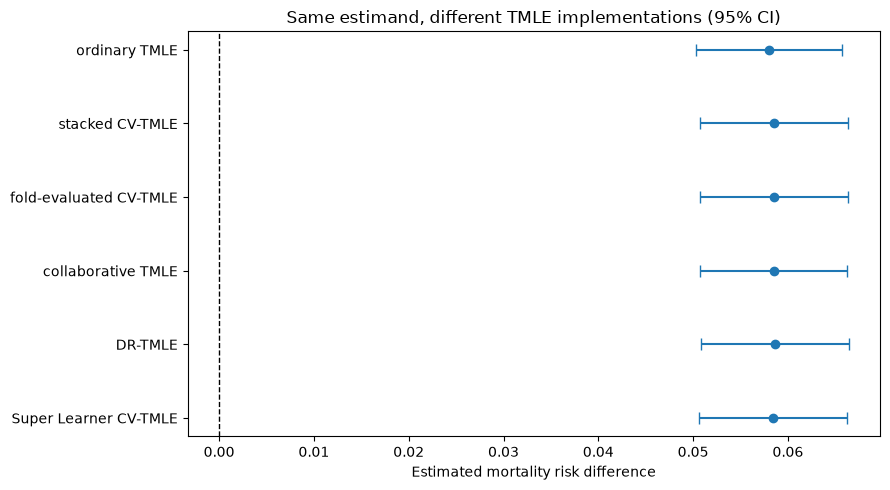

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = comparison.dropna(subset=["std_error"]).reset_index(drop=True)
y = np.arange(len(plot_data))
xerr = np.vstack(
    [
        plot_data["estimate"] - plot_data["ci_low"],
        plot_data["ci_high"] - plot_data["estimate"],
    ]
)
ax.errorbar(plot_data["estimate"], y, xerr=xerr, fmt="o", capsize=4)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(y, plot_data["method"])
ax.set_xlabel("Estimated mortality risk difference")
ax.set_title("Same estimand, different TMLE implementations (95% CI)")
ax.invert_yaxis()
fig.tight_layout()

Agreement across estimators is reassuring about numerical stability, but it does not prove identification. Similar estimates can share the same unmeasured-confounding bias. Meaningful differences can also be informative: IPW is most exposed to extreme propensity estimates, while flexible nuisance learning can change both the initial outcome regression and the clever covariate.

### Which variant to reach for

They agree here, and that is the expected result rather than a null finding: with parametric
nuisance learners on 12,000 rows and no serious positivity strain, the conditions that separate
these estimators are absent. The differences appear when those conditions are present.

- **Ordinary TMLE** is the right default when the nuisance learners are genuinely parametric and
  low-dimensional, so that fitting and targeting on the same rows costs no meaningful overfitting.
- **CV-TMLE** is what you want as soon as the learners are flexible. Cross-fitting removes the
  empirical-process (Donsker) condition an ordinary fit needs — which is exactly the condition a
  gradient-boosted nuisance is not entitled to. Prefer it whenever the model library is adaptive,
  as in the Super Learner fit above.
- **C-TMLE** earns its cost under near-positivity violations. A covariate that predicts treatment
  strongly but confounds weakly inflates the variance of an ordinary propensity score for no bias
  reduction; C-TMLE can decline to include it, because it selects against target-parameter risk
  rather than treatment prediction.
- **DR-TMLE** is for the case where you doubt one nuisance in particular. Ordinary TMLE is doubly
  robust for *consistency* — the point estimate survives one wrong model — but its confidence
  interval generally is not. DR-TMLE's reduced-dimension corrections extend that robustness to
  inference.

The cost ordering runs the same way, so the guidance is not "always use the most elaborate one."
Choose the weakest assumption set your data and learners actually require.

### Every estimator carries its own validation record, not just the last one

Comparing point estimates and intervals is not enough to justify putting six rows in one table.
Each fit stored its own diagnostics, so each can answer whether *its* targeting converged and *its*
support held. `validate()` runs the inexpensive battery — it never refits — and `to_frame()` makes
it stackable across methods.

In [13]:
all_fits = {**tmle_results, "Super Learner CV-TMLE": flexible_result}
validation_rows = []
for label, fitted in all_fits.items():
    frame = fitted.validate().to_frame()
    frame.insert(0, "method", label)
    validation_rows.append(frame)

validation_table = pd.concat(validation_rows, ignore_index=True)
validation_status = validation_table.pivot(index="method", columns="check", values="status")
validation_status.loc[list(all_fits)]

check,nuisance_models,score_equations,support
method,,,
ordinary TMLE,passed,passed,passed
stacked CV-TMLE,passed,passed,passed
fold-evaluated CV-TMLE,passed,passed,passed
collaborative TMLE,passed,passed,passed
DR-TMLE,passed,passed,passed
Super Learner CV-TMLE,passed,passed,passed


A wall of `passed` is a weaker claim than it looks, and it is worth being precise about what it
does and does not license.

It says: targeting solved the empirical score equations each estimator posed, the stored support
diagnostics raised no material warning, and out-of-fold nuisance fits with calibration diagnostics
exist for every one of them. Those are *observable* implications of the estimation procedure.

It does not say the estimates are unbiased. Every check here is computed from the observed data
under the assumed identification; none of them can see a missing confounder, an ill-defined
intervention, or a wrong adjustment set. A fit with unmeasured confounding passes all three
cheerfully. That is the division of labour between this table and the sensitivity analysis in
section 8.

### What C-TMLE actually selected

C-TMLE is the one variant above whose behaviour is directly inspectable: it exposes the sequence of
nested treatment models it searched and the position it stopped at.

In [14]:
ctmle_path = tmle_results["collaborative TMLE"].extra["ctmle"]
print(ctmle_path.summary())

Collaborative TMLE selection
strategy = greedy; preorder = n/a; target = ate (ate); criterion = cross-validated penalized log-likelihood loss

k   covariates in g                                                                                                                                                                                                                                     steps  risk     cv risk     
--  --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------  -----  -------  -------  ---
0   (intercept)                                                                                                                                                                                                                                         1      1655.8   1656.14     
1   mplbir_reg_missing    

C-TMLE walked a sequence of nested treatment models upward from an intercept-only one and
stopped where cross-validated penalized loss was lowest.

The informative line is the last one: it **left out `meduc6`, `mrace`, and `phyper`**. Those three
are still in the outcome regression and still in the declared adjustment set — C-TMLE is not
claiming they are not confounders. It is claiming that, for this target parameter, putting them in
the *propensity* model would have cost more variance than the bias it removed. That is the concrete
meaning of "selects against target-parameter risk rather than treatment prediction": a covariate can
be worth adjusting for in $Q$ and not worth adjusting for in $g$.

Notice also that the cross-validated risk column is nearly flat along the whole path, moving only
between about 1656.1 and 1656.6. The selection is real, but the surface it optimizes over is
shallow — which is consistent with C-TMLE landing on 0.0585, the same value as plain stacked
CV-TMLE. On data with a genuine near-positivity problem, this is the column that would show
structure.

## 7. Ask the question on more than one scale

A risk difference is not the only useful summary. `cleverly` makes the estimand a typed object, so we can state whether we want counterfactual risks, effects among exposed or unexposed children, a risk or odds ratio, or a population-attributable measure. Each line below is a separate causal question fit with the same stacked CV-TMLE configuration.

ATT and ATC change the target population. Risk and odds ratios change the contrast scale. PAR and PAF compare the observed population risk with the counterfactual risk under the reference exposure. These are not interchangeable restatements.

In [15]:
estimands = {
    "counterfactual risk": CounterfactualMean(),
    "ATT": ATT(reference=0),
    "ATC": ATC(reference=0),
    "risk ratio": RiskRatio(reference=0),
    "odds ratio": OddsRatio(reference=0),
    "population attributable risk": PopulationAttributableRisk(reference=0),
    "population attributable fraction": PopulationAttributableFraction(reference=0),
}
scale_rows = []
scale_results = {}
for question, estimand in estimands.items():
    fitted = point_study.estimate(estimand, method=methods["stacked CV-TMLE"])
    scale_results[question] = fitted
    for parameter, estimate in fitted.estimates.items():
        scale_rows.append(
            {
                "question": question,
                "parameter": parameter,
                "estimate": estimate.psi,
                "std_error": estimate.std_error,
                "ci_low": estimate.ci[0],
                "ci_high": estimate.ci[1],
            }
        )
effect_scales = pd.DataFrame(scale_rows)
effect_scales

,question,parameter,estimate,std_error,ci_low,ci_high
0,counterfactual risk,ey[0],0.0045,0.0009,0.0027,0.0064
1,counterfactual risk,ey[1],0.0630,0.0039,0.0554,0.0706
2,ATT,att,0.0610,0.0041,0.0530,0.0690
3,ATC,atc,0.0558,0.0041,0.0478,0.0639
4,risk ratio,rr,13.9248,0.2151,9.1355,21.2249
5,odds ratio,or,14.7942,0.2172,9.6655,22.6444
6,population attributable risk,par,0.0314,0.0021,0.0272,0.0356
7,population attributable fraction,paf,0.8740,0.0255,0.8239,0.9241


These seven rows are not seven summaries of one number, and reading them together shows why. The
counterfactual risks are 0.0045 under no low birth weight and 0.0630 under it; everything else is a
different way of contrasting those two.

- **The ratio scales are enormous because the reference risk is tiny.** A risk ratio near 14 pairs
  with a risk difference of 0.058: on the absolute scale this is about six excess deaths per
  hundred, on the relative scale a fourteen-fold increase. Neither is wrong, and only the risk
  difference carries the public-health magnitude directly.
- **The odds ratio (14.79) exceeds the risk ratio (13.92).** The odds ratio always overstates the
  risk ratio away from the null, and the familiar "with a rare outcome the two coincide"
  approximation is visibly *approximate* here: the outcome is rare in the control arm but 6.3% in
  the treated arm, which is enough to separate them.
- **ATT (0.0610) exceeds ATC (0.0558).** The effect is larger among children who actually had low
  birth weight than among those who did not. That is effect heterogeneity across target
  populations, and it is why the target population belongs in the question rather than in a
  footnote.
- **PAF is 0.874 while PAR is 0.0314.** A large fraction of a small risk is still a small risk. The
  PAF says most of the mortality contrast in this sample is attributable to low birth weight under
  the stated assumptions; the PAR says the absolute burden that corresponds to is about three
  deaths per hundred.

Every row shares the same identification assumptions and the same stacked CV-TMLE fit. Choosing the
scale is a reporting decision, not a way to obtain a more favourable answer.

## 8. Diagnose before interpreting

A confidence interval is conditional on identification and nuisance-rate conditions. It does not diagnose them. Every cleverly result retains the fitted artifacts needed for support, nuisance, score-equation, and sensitivity checks.

- The **support report** asks whether treatment probabilities approach the truncation bounds or weights concentrate on a few observations.
- The **nuisance report** summarizes predictive performance and, for Super Learners, library weights.
- The **score report** checks that targeting solved the intended empirical efficient-score equations.
- **Omitted-variable sensitivity** asks how strong residual associations with treatment and outcome would need to be to move the ATE. It quantifies a scenario; it does not discover the missing variable.

`run_all()` rolls these up into one status per check. Two rows in it are worth reading before the detail:

- `refute` reports `unavailable`. That is a deliberate default, not a failure: refutation re-fits the nuisance models, so it costs another full fit and is opt-in through `run_all(include_refits=True)`.
- `stagewise` reports `not_applicable`, because a point-treatment fit has no sequential nodes. It becomes a real check in section 9.

In [16]:
print(flexible_result.diagnostics.run_all().summary())
print()
print(flexible_result.validate().summary())

diagnostic       status          detail                                                               
---------------  --------------  ---------------------------------------------------------------------
support          passed          no material support warning in the stored diagnostic                 
nuisance_models  passed          completed from stored fitted artifacts                               
score_equations  passed          completed from stored fitted artifacts                               
refute           unavailable     not run by default because it refits models; pass include_refits=True
stagewise        not_applicable  a point-treatment fit has no sequential nodes                        

Validation: PASS
----------------
check            status  detail                                                            
---------------  ------  ------------------------------------------------------------------
score_equations  passed  all 2 stored score checks converged

### Read the detail, not only the status

The roll-up above says every check passed; its `detail` column says only that the check ran from
stored artifacts. The reports underneath it carry the numbers, and they answer questions the
comparison table could not.

In [17]:
print(flexible_result.diagnostics.nuisance_models().summary())
print()
print(flexible_result.diagnostics.score_equations().summary())

Nuisance model diagnostics (out of fold)
----------------------------------------
model       auc     brier   log_loss  r2  mse  cal_slope
----------  ------  ------  --------  --  ---  ---------
propensity  0.6101  0.2405  0.6738    -   -    0.9547   
outcome     0.7666  0.0335  0.1377    -   -    0.8215   

propensity: super learner weights logistic=0.863, boosting=0.137

outcome: super learner weights logistic=0.888, boosting=0.112

VERDICT: nuisance fits look reasonable.

Score-equation check
--------------------
target  kind             |score|    before     threshold  ratio     ok 
------  ---------------  ---------  ---------  ---------  --------  ---
mean    fluctuation      1.868e-14  1.553e-03  3.649e-08  5.12e-07  yes
ate     influence curve  1.868e-14  -          3.649e-08  5.12e-07  yes

PASS: the targeting step solved the estimated efficient score equation.


The nuisance report answers two questions no estimate table can.

**Which candidates did the ensemble actually use?** Both Super Learners put roughly 86–89% of their
weight on the plain logistic model and only 11–14% on gradient boosting. The flexible library was
available and cross-validation largely declined it. That is the concrete version of "more
flexibility is not automatically better" from earlier in this section: we paid for the option, and
the ensemble reports it was barely needed. A weight of 1.0 on any single member would be worth
pausing over in the other direction — it means the library offered no real choice.

**Are the fits calibrated, and is treatment too predictable?** Propensity AUC is 0.61, which is poor
*prediction* and good *news*: treatment is hard to predict from these covariates, which is precisely
why the overlap diagnostics below are healthy. The alarming case is the opposite one — an AUC near 1
means near-deterministic assignment and a positivity violation. The outcome model's calibration
slope of 0.82 sits modestly below the ideal 1.0, indicating predictions a little more spread out
than the data support.

The score check is worth reading numerically rather than as a status. The `|score|` column reads
1.9e-14 against a threshold of 3.6e-8, having started at 1.6e-3 before targeting — machine zero relative to the
sampling variability. The quantity that would matter is a `ratio` approaching 1: that would mean
targeting had not converged and the influence-curve interval was not entitled to its coverage.

In [18]:
positivity = flexible_result.sensitivity.positivity()
omitted = flexible_result.sensitivity.omitted_confounding("ate", cf_y=0.05, cf_d=0.05)
print(positivity.summary())
print()
print(omitted.summary())

Positivity / overlap diagnostics
--------------------------------
n = 12000; propensity truncated to [0.004859, 0.9951]

g(W) quantile  0%      1%      5%      25%     50%     75%     95%     99%     100%  
-------------  ------  ------  ------  ------  ------  ------  ------  ------  ------
overall        0.2868  0.3494  0.3855  0.4375  0.4898  0.5878  0.7005  0.7719  0.9258
treated        0.2999  0.3550  0.3921  0.4494  0.5115  0.6152  0.7178  0.7893  0.9258
control        0.2868  0.3460  0.3821  0.4284  0.4707  0.5482  0.6725  0.7474  0.8745

arm      n     effective n  ESS / n  top 1% weight  top 5% weight
-------  ----  -----------  -------  -------------  -------------
treated  6174  5955.1       0.965    0.015          0.070        
control  5826  5493.6       0.943    0.023          0.088        

threshold  P(g < t)  P(g > 1-t)
---------  --------  ----------
0.01       0.0000    0.0000    
0.025      0.0000    0.0000    
0.05       0.0000    0.0000    
0.1        0.0000    0.

### Reading the overlap block

- The quantile table puts $g(W)$ between 0.29 and 0.93, with treated and control distributions
  substantially overlapping. Nothing approaches 0 or 1. This is an unusually comfortable positivity
  picture, and it is worth noticing that it comes from a *weak* propensity model — see the AUC of
  0.61 above.
- **`most extreme untruncated g(W) = 0.0742` does not contradict the `0.2868` in the `0%` column
  above it.** The quantile row reports $P(A=1\mid W)$ directly; the extremity line reports the
  closest approach to *either* boundary, that is $\min_i \min\{g_i,\,1-g_i\}$. The unit with
  $g = 0.9258$ sits 0.0742 away from 1. Both lines describe the same child.
- `ESS / n` is 0.965 treated and 0.943 control, so weighting costs 4–6% of the effective sample.
  The rule of thumb worth carrying is that values below roughly 0.5 mean the estimate is resting on
  a minority of the data.
- **0 units truncated.** The bounds never bound anything, so nothing in this fit depends on where
  they were set — which is exactly the assumption the IPW row in section 6 could not make.
- `max |clever covariate| (mean): 7.97` is the largest value of the $H(A,W)$ we built by hand in
  section 5. It bounds how hard any single observation can pull the targeting step; 7.97 across
  12,000 rows is unremarkable.

### Reading the sensitivity block

Under the assumed scenario — a confounder explaining 5% of the residual variation in both treatment
and outcome — the bias-adjusted bounds are [0.039, 0.078] and the sign survives.

The **robustness value** is the number to quote, because it needs no assumed scenario at all.
$RV = 0.1445$ says a confounder would have to explain 14.5% of the residual variation in *both*
treatment and outcome to move the ATE to zero; $RV_a = 0.1337$ does the same for the 95% confidence
bound. Two cautions come with it. First, RV is a threshold, not a probability: it says nothing about
whether such a confounder is plausible here, which is a subject-matter judgement and not a
statistical one. Second, recall that adjustment moved the crude estimate by only 0.003 — the
measured covariates jointly explain very little of this contrast. That is mild circumstantial
evidence that a single unmeasured covariate reaching 14.5% on both margins would be unusual in this
data set, but it is an argument about *this* covariate set, not a proof.

`sensitivity.benchmark(covariates=[...])` is the tool that turns that judgement into a comparison
against a named observed covariate — "as strong as `tobacco`" rather than "5%". It refits nuisance
models, so it is not run here.

Those two calls are the ones this fit supports. As with estimators, the sensitivity facade declares
its whole menu and refuses the rest by name and reason.

In [19]:
print(flexible_result.sensitivity.run_all().summary())

diagnostic           status          detail                                                            
-------------------  --------------  ------------------------------------------------------------------
omitted_confounding  passed          completed from the fitted method's declared artifacts             
benchmark            unavailable     not run by default because it refits nuisance models              
missingness          not_applicable  the identified functional has no observation/missingness mechanism


The same discipline as the method table in section 4, applied to sensitivity analysis.
`omitted_confounding` ran from the fit's stored artifacts. `benchmark` is available in principle
and withheld by default because it refits nuisance models. `missingness` is `not_applicable`
rather than `unavailable`, and the difference is real: this estimand has no observation mechanism
to tilt, so there is nothing missing to be sensitive to — as opposed to a check that exists but
this fit cannot serve. Compare this map with the same call on the longitudinal fit at the end of
section 9.

### What we learned from the point-treatment analysis

The sequence matters more than any single estimate:

1. The crude contrast answered an associational question.
2. Identification converted the scientific claim into an observed-data functional and exposed its assumptions.
3. G-computation and IPW showed the two nuisance-model routes, and one hand-built fluctuation showed what targeting adds to them.
4. TMLE combined them, targeted the parameter, and supplied clustered influence-curve inference.
5. Cross-fitting separated nuisance training from evaluation; C-TMLE selected its treatment model against target-parameter risk, and DR-TMLE added reduced-dimension corrections, both of which change how nuisance bias reaches the estimate.
6. Diagnostics checked observable implications on every fitted estimator, while sensitivity analysis probed an unobservable failure mode.

None of steps 3–6 repairs an implausible DAG, an ill-defined intervention, or unmeasured confounding. Statistical sophistication comes after a defensible causal question.

## 9. A pedagogical longitudinal extension

The original CEVAE benchmark is not longitudinal. To demonstrate LTMLE without pretending otherwise, we now formulate a **new, illustrative prenatal-care question** from time-ordered fields in the same records:

- $A_1$: prenatal care began in the first trimester (`mpre5 == 1`);
- $L_2$: pregnancy-associated hypertension, a time-varying risk marker observed before the second care summary;
- $A_2$: higher prenatal-visit intensity (`nprevistq >= 3`); and
- $Y$: mortality by age three.

We compare the static regimes `always` $(1,1)$ and `never` $(0,0)$. This operationalization is intentionally simple and should not be read as a validated clinical intervention. In particular, visit totals depend on gestational duration and care access, treatment versions are heterogeneous, and complete-case restriction adds a selection assumption. Its purpose is to show the data structure and sequential identifying logic.

In [20]:
longitudinal_data = twins.dropna(subset=["mpre5", "nprevistq", "phyper"]).copy()
longitudinal_data["early_prenatal_care"] = (longitudinal_data["mpre5"] == 1).astype(int)
longitudinal_data["pregnancy_hypertension"] = longitudinal_data["phyper"].astype(int)
longitudinal_data["higher_visit_intensity"] = (longitudinal_data["nprevistq"] >= 3).astype(int)

LONG_BASELINE = (
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "tobacco",
    "alcohol",
    "birth_order",
)
for column in LONG_BASELINE:
    longitudinal_data[column] = (
        longitudinal_data[column].fillna(longitudinal_data[column].median()).astype(float)
    )

long_summary = (
    longitudinal_data[
        ["early_prenatal_care", "pregnancy_hypertension", "higher_visit_intensity", "mortality_3y"]
    ]
    .mean()
    .to_frame("prevalence")
)
long_summary.loc["children retained", "prevalence"] = len(longitudinal_data)
long_summary

,prevalence
early_prenatal_care,0.7965
pregnancy_hypertension,0.0656
higher_visit_intensity,0.3560
mortality_3y,0.0341
children retained,10764.0000


Two of these prevalences already forecast the positivity problem. Early prenatal care is the norm
(about 80%) while higher visit intensity is not (about 36%), so the `never` regime — declining
both — describes an uncommon combination. Complete-case restriction on `mpre5`, `nprevistq`, and
`phyper` also drops roughly 1,200 children relative to the point-treatment sample, which is the
selection assumption named above rather than a free reduction.

Longitudinal exchangeability is sequential: at each treatment node, the future counterfactual outcome must be independent of that treatment given the observed past. At the second node, history includes baseline, $A_1$, and $L_2$. Positivity must also hold for each regime at each observed history. LTMLE works backward through these histories, targeting a sequence of outcome regressions with cumulative treatment probabilities.

In [21]:
long_study = CausalStudy(
    longitudinal_data,
    design=LongitudinalTreatment(
        outcome="mortality_3y",
        treatment=("early_prenatal_care", "higher_visit_intensity"),
        baseline=LONG_BASELINE,
        time_varying=((), ("pregnancy_hypertension",)),
        cluster="pair_id",
        outcome_family="binomial",
    ),
)
regime_effect = long_study.identify(RegimeContrast({"always": 1, "never": 0}, reference="never"))
print(regime_effect.summary())
pd.DataFrame([vars(item) for item in regime_effect.available_methods()])

contrast of each regime against the reference
identified by explicit-adjustment: sequential g-formula under the declared treatment regimen
adjustment/history: ['mager8', 'meduc6', 'mrace', 'dmar', 'mplbir_reg', 'data_year', 'diabetes', 'chyper', 'tobacco', 'alcohol', 'birth_order']
assumptions:
  - consistency and no interference
  - sequential exchangeability given the recorded history at every node
  - sequential positivity for treatment and remaining under observation


,name,available,reason
0,tmle,True,NaN
1,collaborative_tmle,False,no collaborative score is evidenced for this f...
2,drtmle,False,no reduced-dimension correction is evidenced f...
3,riesz_tmle,False,the direct-Riesz engine and intervention-state...
4,ep,False,EP requires a conditional-contrast estimand an...


In [22]:
long_result = regime_effect.estimate(
    outcome_learner=LinearRegression(),
    pseudo_learner=LinearRegression(),
    treatment_learner=LogisticRegression(max_iter=3_000),
    n_folds=3,
    learner_folds=3,
    simultaneous=False,
    random_state=SEED,
)
print(long_result.summary())
print()
print(long_result.diagnostics.run_all().summary())
print()
print(long_result.validate().summary())

Longitudinal TMLE (2 time points, n = 10764)

parameter                     estimate  std. error  95% CI              p-value
----------------------------  --------  ----------  ------------------  -------
ate_regimen[always vs never]  -0.0248   0.0057      [-0.0360, -0.0135]  <1e-4  

  time points: 2
  outcome family: binomial
  regimens: always=(1/1), never=(0/0)
  reference: never
  cross-fitting: 3 fold(s)
  g_bounds: fixed [0.01, 1] on each cumulative treatment-and-censoring probability (package default; R ltmle-compatible heuristic -- inspect truncation diagnostics)
  confidence level: 95%
  random_state: 2026
  causal estimand: contrast of each regime against the reference
  identification: explicit-adjustment; sequential g-formula under the declared treatment regimen
  identification assumptions: consistency and no interference; sequential exchangeability given the recorded history at every node; sequential positivity for treatment and remaining under observation
  clusters = 

Every diagnostic passed, the validation battery passed, and the interval excludes zero — and this
is still the least secure estimate in the notebook. The reason is in the last two lines of the
summary rather than anywhere in the diagnostics table:

```text
always: 3570 of 10764 units followed it throughout; max weight 12.8, effective n 3073
never:  1928 of 10764 units followed it throughout; max weight 39.2, effective n 1122
```

The `never` regime — declining early prenatal care *and* higher visit intensity — is followed
throughout by 1,928 of 10,764 children, and after weighting contributes an effective sample of
about 1,122, roughly a tenth of the nominal $n$. Its maximum cumulative weight of 39.2 means one
child's outcome carries about thirty-nine times the influence of an average one.

This is what sequential positivity costs. At each node a unit must have had a non-negligible chance
of the assigned action given everything before it, and the cumulative probability is a *product*
across nodes, so the strain compounds rather than averages. Early prenatal care is roughly 80%
prevalent, which makes `never` the rarer path and the thinner arm.

For reading the result, the distinction that matters is this. The standard error *already* accounts
for the lost precision — that is what the effective-$n$ calculation does, and it is why this
interval is wide relative to its estimate compared with the point-treatment ATE. What no standard
error accounts for is extrapolation. With about 1,122 effective observations informing one arm, a
`passed` support check means "no truncation-driven fragility was detected in the stored diagnostic,"
not "this regime is well supported by the data." Read −0.0248 as an illustration of the machinery,
consistent with the caveats that opened this section.

### Per-node support is where a longitudinal fit actually strains

The point-treatment fit had one treatment mechanism to satisfy. This one has two, and a unit must
comply at *both* nodes to inform a regime. `diagnostics.stagewise()` opens the per-node table that
`run_all()` summarizes in a single row; for a longitudinal fit `diagnostics.support()` routes to the
same report, because per-node cumulative weights *are* the support question here.

`sensitivity.run_all()` is shown beside it to make the boundary explicit. It is the same argument
section 10 makes about estimators, applied to sensitivity analysis.

In [23]:
print(long_result.diagnostics.stagewise().to_frame())
print()
print(long_result.sensitivity.run_all().summary())

  regimen  time  n_followed  share_assigned_1  max_weight  effective_n  \
0  always     1        8574               1.0      5.8726    8152.5313   
1  always     2        3570               1.0     12.8460    3073.4365   
2   never     1        2190               0.0     32.0262    1335.9919   
3   never     2        1928               0.0     39.1604    1122.2763   

   share_truncated  epsilon  converged  
0              0.0  -0.0077       True  
1              0.0  -0.0345       True  
2              0.0   0.0266       True  
3              0.0  -0.0944       True  

diagnostic           status       detail                                                                
-------------------  -----------  ----------------------------------------------------------------------
omitted_confounding  unavailable  no longitudinal omitted-confounder derivation                         
benchmark            unavailable  benchmarking requires a fitted point-treatment estimator configuration
mis

The per-node table makes the compounding explicit instead of leaving it as one final number.

Follow `effective_n` down each regime: `always` falls 8,153 → 3,073 and `never` falls 1,336 →
1,122. Node 1 already separates them, because 8,574 children began prenatal care early and only
2,190 did not. Node 2 then multiplies each by its own compliance probability. `max_weight` climbs
along both paths — 5.9 → 12.8 and 32.0 → 39.2 — which is the same phenomenon read on the weight
scale rather than the sample-size scale.

The `epsilon` column rewards a glance as well. The largest targeting correction in the entire fit
(−0.0944) lands on `never` at node 2 — precisely the node with the least support. That is not a
malfunction; the fluctuation is doing what it should. It is a reminder that the targeting step is
working hardest exactly where the data are thinnest, and `converged = True` reports that the
fluctuation solved its equation, not that the equation rested on many observations.

The sensitivity map underneath refuses all three operations, each with a reason specific to the
longitudinal family: `omitted_confounding` has no published derivation for a sequential fit,
`benchmark` needs a point-treatment configuration, and the missingness tilt has no longitudinal
adapter. Contrast that with section 8, where the first ran and `missingness` was
`not_applicable`. Being told a sensitivity analysis is unavailable is far more useful than being
handed the point-treatment formula applied to a parameter it was never derived for.

The longitudinal estimate answers a different question from the low-birth-weight ATE. Its treatment is a two-node strategy, its adjustment set is a history rather than one baseline vector, and its clever covariates use cumulative treatment probabilities. C-TMLE and DR-TMLE correctly appear unavailable here because cleverly has no longitudinal derivation for those variants. An unavailable method is a scientific boundary, not an invitation to substitute a nearby estimator silently.

## 10. Why other cleverly methods are not used here

Using every API on one dataset would make the analysis less honest. The following implemented families need a different scientific question or data structure:

| family | why it is not appropriate for this worked question |
| --- | --- |
| continuous modified treatment policies | birth weight is not a manipulable continuous dose with a defensible shift intervention here |
| incremental propensity interventions | these tilt a treatment-assignment mechanism; our primary question is a static binary contrast |
| controlled direct effects | a mediator intervention and additional identification assumptions would need to be defended |
| missing-outcome TMLE | the published mortality outcome has no missing values |
| survival and competing-risk LTMLE | only a single three-year mortality indicator is available, not event-time nodes or competing causes |
| marginal structural model projections | two static regimes suffice for the teaching contrast; a projection requires a prespecified regimen set and working model |
| multi-arm TMLE | the exposure was deliberately defined as binary |

A good analysis uses the most complex estimator justified by its question and observed data—not the largest number of methods available.

## 11. Reproducibility record

A production report should also record the exact notebook, data commit, software environment, estimand, adjustment/history variables, learner libraries, fold plan, treatment bounds, missing-data handling, clustering, and all diagnostics inspected. `cleverly` results retain normalized method configuration and provenance; saving a result uses joblib and should only be loaded from a trusted source.

In [24]:
pd.Series(
    {
        "python": platform.python_version(),
        "cleverly": cleverly.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "CEVAE data commit": COMMIT,
        "seed": SEED,
        "sampled pairs": N_PAIRS,
    },
    name="value",
)

python                                                 3.13.7
cleverly                                                0.1.0
numpy                                                   2.4.6
pandas                                                  3.0.5
scikit-learn                                            1.9.0
CEVAE data commit    9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd
seed                                                     2026
sampled pairs                                            6000
Name: value, dtype: object